# give me a python code to create any graph with the weight and heuristic values



Graph Structure:
  Node 'S' (Heuristic: 10) -> Neighbors: {'A': 6, 'C': 3}
  Node 'A' (Heuristic: 8) -> Neighbors: {'S': 6, 'B': 3, 'D': 2}
  Node 'B' (Heuristic: 5) -> Neighbors: {'A': 3, 'Goal': 5}
  Node 'C' (Heuristic: 7) -> Neighbors: {'S': 3, 'D': 1}
  Node 'D' (Heuristic: 3) -> Neighbors: {'A': 2, 'C': 1, 'Goal': 4}
  Node 'Goal' (Heuristic: 0) -> Neighbors: {'B': 5, 'D': 4}

Drawing graph... Please check for a new window!


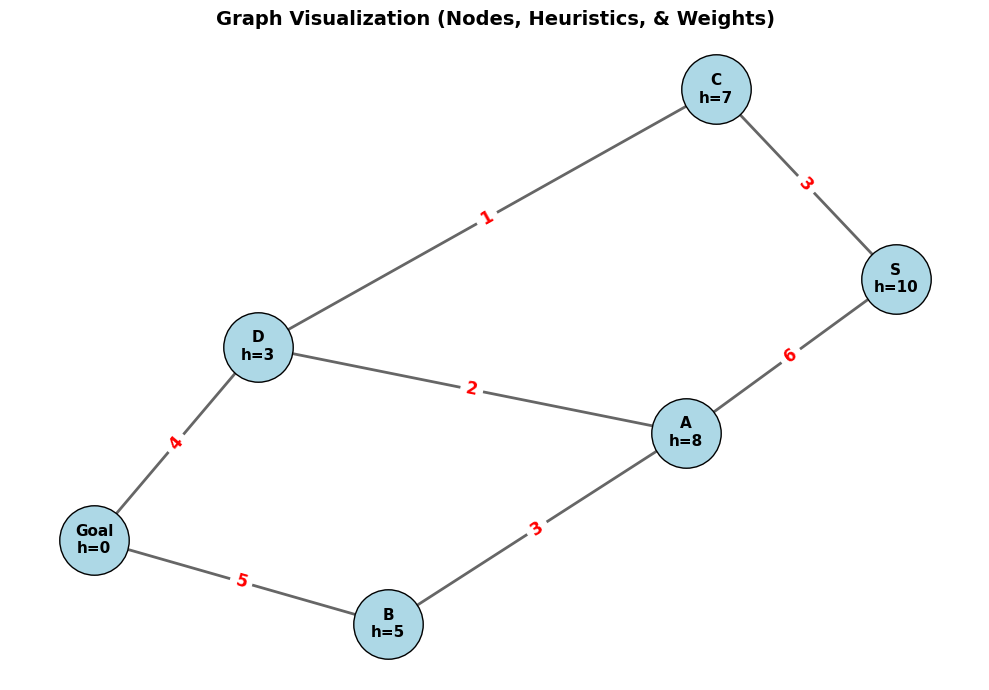

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

class Graph:
    def __init__(self):
        # Stores edges and weights: { node: {neighbor: weight, ...}, ... }
        self.edges = {}
        # Stores heuristic values: { node: heuristic_value, ... }
        self.heuristics = {}

    def add_node(self, node, heuristic=0):
        """Adds a node with an optional heuristic value."""
        if node not in self.edges:
            self.edges[node] = {}
        self.heuristics[node] = heuristic

    def add_edge(self, from_node, to_node, weight, bidirectional=True):
        """Adds an edge between two nodes with a specific weight."""
        if from_node not in self.edges:
            self.add_node(from_node)
        if to_node not in self.edges:
            self.add_node(to_node)

        self.edges[from_node][to_node] = weight
        if bidirectional:
            self.edges[to_node][from_node] = weight

    def get_neighbors(self, node):
        """Returns a dictionary of neighbors and their edge weights."""
        return self.edges.get(node, {})

    def get_heuristic(self, node):
        """Returns the heuristic value of a node."""
        return self.heuristics.get(node, float('inf'))

    def display(self):
        """Prints the graph's structure to the console."""
        print("Graph Structure:")
        for node, neighbors in self.edges.items():
            h_val = self.heuristics.get(node, 0)
            print(f"  Node '{node}' (Heuristic: {h_val}) -> Neighbors: {neighbors}")

    def draw(self):
        """Visually draws the graph using matplotlib and networkx."""
        # 1. Convert our dictionary graph into a NetworkX graph for plotting
        G = nx.Graph()

        for node in self.heuristics:
            G.add_node(node)

        for from_node, neighbors in self.edges.items():
            for to_node, weight in neighbors.items():
                G.add_edge(from_node, to_node, weight=weight)

        # 2. Set up the visual plot
        plt.figure(figsize=(10, 7))

        # Generate coordinates for nodes to space them out nicely
        pos = nx.spring_layout(G, seed=42)

        # 3. Draw the colored nodes
        nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='lightblue', edgecolors='black')

        # 4. Draw the Node Labels (showing Name and Heuristic)
        labels = {node: f"{node}\nh={self.heuristics.get(node, 0)}" for node in G.nodes()}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=11, font_weight='bold')

        # 5. Draw the connecting lines (edges)
        nx.draw_networkx_edges(G, pos, width=2, alpha=0.6)

        # 6. Draw the Edge Weights (costs) in red
        edge_labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=12, font_weight='bold')

        # 7. Final rendering touches
        plt.title("Graph Visualization (Nodes, Heuristics, & Weights)", fontsize=14, fontweight='bold')
        plt.axis('off') # Hide the background grid/axes
        plt.tight_layout()

        # This will open a window showing your graph
        plt.show()

# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    g = Graph()

    # Add nodes with heuristics
    g.add_node('S', heuristic=10)
    g.add_node('A', heuristic=8)
    g.add_node('B', heuristic=5)
    g.add_node('C', heuristic=7)
    g.add_node('D', heuristic=3)
    g.add_node('Goal', heuristic=0)

    # Add edges with weights
    g.add_edge('S', 'A', weight=6, bidirectional=True)
    g.add_edge('S', 'C', weight=3, bidirectional=True)
    g.add_edge('A', 'B', weight=3, bidirectional=True)
    g.add_edge('A', 'D', weight=2, bidirectional=True)
    g.add_edge('C', 'D', weight=1, bidirectional=True)
    g.add_edge('B', 'Goal', weight=5, bidirectional=True)
    g.add_edge('D', 'Goal', weight=4, bidirectional=True)

    # Print to console
    g.display()

    # OPEN THE VISUAL GRAPH
    print("\nDrawing graph... Please check for a new window!")
    g.draw()



## Apply working of A* Algorithm on that graph ; then implement it

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# Graph (SAME STRUCTURE AS YOUR GIVEN CODE)
# ==========================================
class Graph:
    def __init__(self):
        self.edges = {}
        self.heuristics = {}

    def add_node(self, node, heuristic=0):
        if node not in self.edges:
            self.edges[node] = {}
        self.heuristics[node] = heuristic

    def add_edge(self, from_node, to_node, weight, bidirectional=True):
        if from_node not in self.edges:
            self.add_node(from_node)
        if to_node not in self.edges:
            self.add_node(to_node)

        self.edges[from_node][to_node] = weight
        if bidirectional:
            self.edges[to_node][from_node] = weight

    def get_neighbors(self, node):
        return self.edges.get(node, {})

    def get_heuristic(self, node):
        return self.heuristics.get(node, float('inf'))

    def display(self):
        print("\nGraph Structure:")
        for node, neighbors in self.edges.items():
            print(f"{node} (h={self.heuristics[node]}) -> {neighbors}")

    # ==========================================
    # DRAW GRAPH (WITH PATH HIGHLIGHT)
    # ==========================================
    def draw(self, path=None):
        G = nx.Graph()

        for node in self.heuristics:
            G.add_node(node)

        for u in self.edges:
            for v, w in self.edges[u].items():
                G.add_edge(u, v, weight=w)

        pos = nx.spring_layout(G, seed=42)

        plt.figure(figsize=(10, 7))

        # Draw normal nodes
        nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='lightblue', edgecolors='black')

        # Highlight path nodes
        if path:
            nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='orange')

        # Labels
        labels = {node: f"{node}\nh={self.heuristics[node]}" for node in G.nodes()}
        nx.draw_networkx_labels(G, pos, labels=labels, font_weight='bold')

        # Draw edges
        nx.draw_networkx_edges(G, pos, width=2)

        # Highlight path edges
        if path:
            path_edges = list(zip(path, path[1:]))
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=4)

        # Edge weights
        edge_labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

        plt.title("A* Search Result (Highlighted Path)")
        plt.axis('off')
        plt.show()


# ==========================================
# A* ALGORITHM (CLEAN VERSION)
# ==========================================
def a_star(graph, start, goal):

    open_list = []
    heapq.heappush(open_list, (0, start))

    came_from = {}

    g_cost = {node: float('inf') for node in graph.edges}
    g_cost[start] = 0

    f_cost = {node: float('inf') for node in graph.edges}
    f_cost[start] = graph.get_heuristic(start)

    while open_list:
        _, current = heapq.heappop(open_list)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            path.reverse()
            return path, g_cost[goal]

        for neighbor, weight in graph.get_neighbors(current).items():

            new_cost = g_cost[current] + weight

            if new_cost < g_cost[neighbor]:
                came_from[neighbor] = current
                g_cost[neighbor] = new_cost
                f_cost[neighbor] = new_cost + graph.get_heuristic(neighbor)

                heapq.heappush(open_list, (f_cost[neighbor], neighbor))

    return None, float('inf')


# ==========================================
# MAIN (SAME GRAPH AS YOUR ORIGINAL PROGRAM)
# ==========================================
if __name__ == "__main__":

    g = Graph()

    g.add_node('S', 10)
    g.add_node('A', 8)
    g.add_node('B', 5)
    g.add_node('C', 7)
    g.add_node('D', 3)
    g.add_node('Goal', 0)

    g.add_edge('S', 'A', 6)
    g.add_edge('S', 'C', 3)
    g.add_edge('A', 'B', 3)
    g.add_edge('A', 'D', 2)
    g.add_edge('C', 'D', 1)
    g.add_edge('B', 'Goal', 5)
    g.add_edge('D', 'Goal', 4)

    g.display()

    print("\nRunning A*...\n")

    path, cost = a_star(g, 'S', 'Goal')

    if path:
        print("Optimal Path:", " -> ".join(path))
        print("Total Cost:", cost)

        print("\nDrawing graph with optimal path...")
        g.draw(path)

    else:
        print("No path found.")